In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score


path_clean = "../data/processed/cleaned_data.csv"

df = pd.read_csv(path_clean)

print("****** Shape des donnees ******")
print(df.shape)

print("****** premiers lignes ******")
print(df.head())


X_cluster = df.drop(
    columns=["Churn", "customerID"],
    errors="ignore"
)

print("****** Variables pour le clustering ******")
print(X_cluster.columns)


# types de variables (numerical ou categorical)
numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_cluster.select_dtypes(
    include=["object", "category"]
).columns

print("****** Variables numeriques ******")
print(numeric_features)

print("****** Variables catergoricals ******")
print(categorical_features)


# PREPROCESSING 

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

X_scaled = preprocessor.fit_transform(X_cluster)

print("****** Donnees apres preprocessing ******")
print(X_scaled.shape)


****** Shape des donnees ******
(7043, 22)
****** premiers lignes ******
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... TechSupport  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...         Yes   
4                No     Fiber optic             No  ...          No   

  StreamingTV Strea

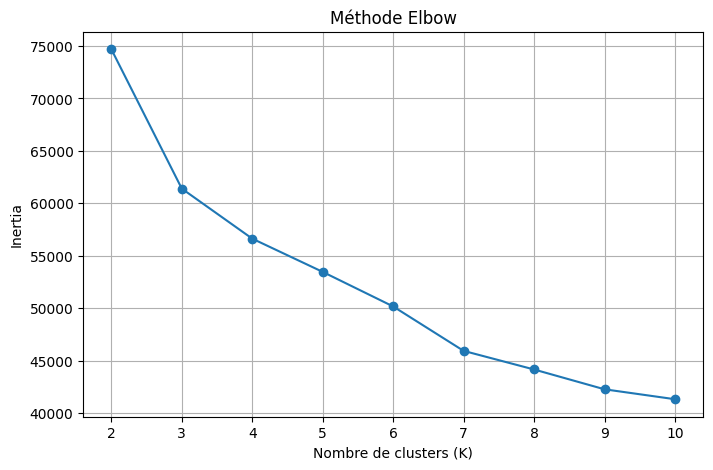

In [2]:


# ****************** ELBOW METHOD ******************

inertias = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertias,
    marker="o"
)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.title("Méthode Elbow")

plt.grid(True)
plt.show()


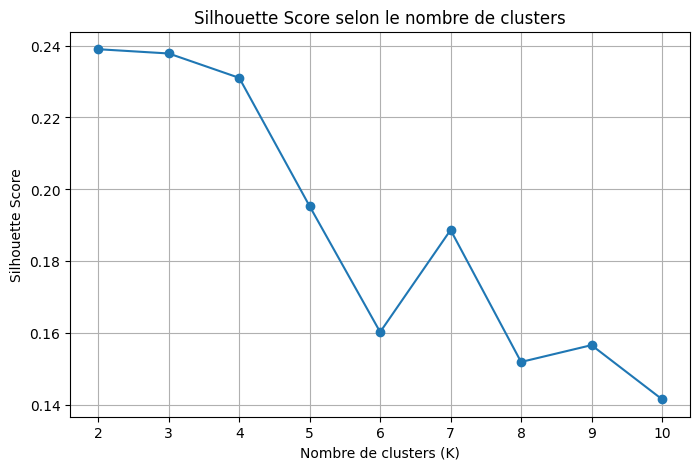

K = 2 → Silhouette Score = 0.2390
K = 3 → Silhouette Score = 0.2378
K = 4 → Silhouette Score = 0.2310
K = 5 → Silhouette Score = 0.1953
K = 6 → Silhouette Score = 0.1604
K = 7 → Silhouette Score = 0.1887
K = 8 → Silhouette Score = 0.1520
K = 9 → Silhouette Score = 0.1567
K = 10 → Silhouette Score = 0.1417
********************************
Meilleur K selon le Silhouette Score : 2
****** Nombre de clients par cluster ******
Cluster
0    1520
1    5523
Name: count, dtype: int64
clusters_data.csv créé avec succès !


In [3]:

# SILHOUETTE SCORE 
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score selon le nombre de clusters")

plt.grid(True)
plt.show()

# ************** COMPARAISON DES SCORES ***************
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k} → Silhouette Score = {score:.4f}")

best_k = list(K_range)[np.argmax(silhouette_scores)]

print("********************************")
print("Meilleur K selon le Silhouette Score :", best_k)
# ****************** K-MEANS FINAL ******************

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_scaled)


# Ajouter le cluster de chaque client

df["Cluster"] = kmeans_final.labels_

# ****************** NOMBRE DE CLIENTS PAR CLUSTER ******************

print("****** Nombre de clients par cluster ******")
print(df["Cluster"].value_counts().sort_index())


# ****************** SAUVEGARDE ******************

df.to_csv(
    "../data/processed/clusters_data.csv",
    index=False
)

print("clusters_data.csv créé avec succès !")

Min_samples : 10


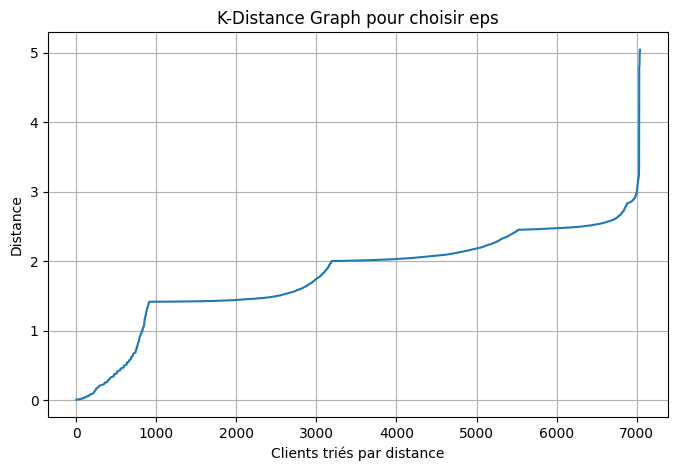

****** Distribution des clusters DBSCAN ******
DBSCAN_Cluster
-1     120
 0    4398
 1    1468
 2    1005
 3      52
Name: count, dtype: int64
Nombre de clusters DBSCAN : 4
Nombre de points considérés comme Noise : 120
****** Evaluation DBSCAN ******
Silhouette Score : 0.172
Davies-Bouldin Score : 1.8143
Calinski-Harabasz Score : 1028.3044


In [4]:
# ****************** PREPARATION DBSCAN ******************

min_samples = 10

print("Min_samples :", min_samples)


# ****************** K-DISTANCE GRAPH ******************

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(8, 5))

plt.plot(distances)

plt.xlabel("Clients triés par distance")
plt.ylabel("Distance")
plt.title("K-Distance Graph pour choisir eps")

plt.grid(True)
plt.show()




# ****************** APPLICATION DE DBSCAN ******************

eps_value = 2.5

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels


# ****************** RESULTATS DBSCAN ******************

print("****** Distribution des clusters DBSCAN ******")

print(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

n_clusters_dbscan = len(
    set(dbscan_labels) - {-1}
)

n_noise = list(dbscan_labels).count(-1)

print(
    "Nombre de clusters DBSCAN :",
    n_clusters_dbscan
)

print(
    "Nombre de points considérés comme Noise :",
    n_noise
)


# ****************** EVALUATION DBSCAN ******************

mask = dbscan_labels != -1

X_dbscan_eval = X_scaled[mask]

labels_dbscan_eval = dbscan_labels[mask]

if len(set(labels_dbscan_eval)) > 1:

    silhouette_dbscan = silhouette_score(
        X_dbscan_eval,
        labels_dbscan_eval
    )

    davies_dbscan = davies_bouldin_score(
        X_dbscan_eval,
        labels_dbscan_eval
    )

    calinski_dbscan = calinski_harabasz_score(
        X_dbscan_eval,
        labels_dbscan_eval
    )

    print("****** Evaluation DBSCAN ******")

    print(
        "Silhouette Score :",
        round(silhouette_dbscan, 4)
    )

    print(
        "Davies-Bouldin Score :",
        round(davies_dbscan, 4)
    )

    print(
        "Calinski-Harabasz Score :",
        round(calinski_dbscan, 4)
    )

*******INTERPRETATION DES PROFILS CLIENTS*******
****** Nombre de clients par cluster ******
Cluster
0    1520
1    5523
Name: count, dtype: int64
****** Profil numerique moyen de chaque cluster ******
         SeniorCitizen  tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend
Cluster                                                                      
0                 0.03   30.67           21.08        665.22            21.13
1                 0.20   32.84           76.78       2726.85            79.47
****** Categorie dominante dans chaque cluster ******
        gender Partner Dependents PhoneService MultipleLines InternetService  \
Cluster                                                                        
0         Male      No         No          Yes            No              No   
1         Male      No         No          Yes           Yes     Fiber optic   

              OnlineSecurity         OnlineBackup     DeviceProtection  \
Cluster                              

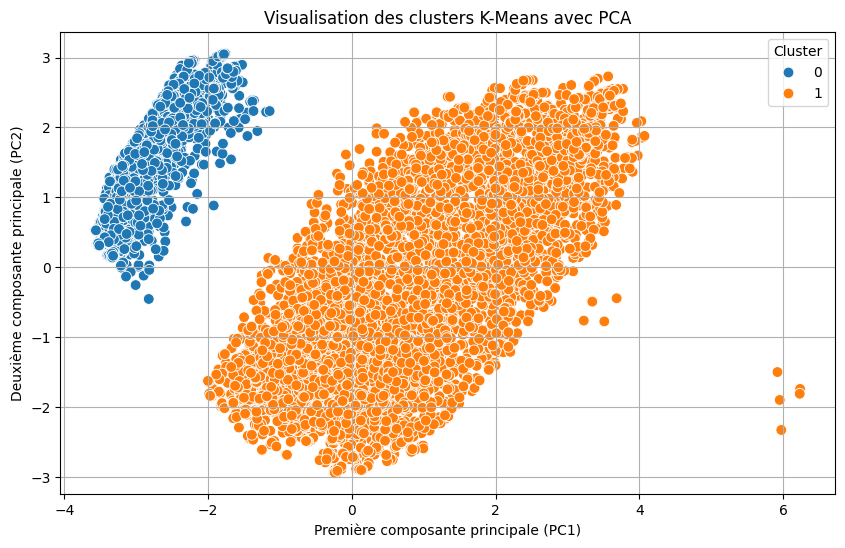

Résultat PCA sauvegardé avec succès !
 clusters_data.csv mis à jour !


In [9]:
#INTERPRETATION DES PROFILS DE CLIENTS

print("*******INTERPRETATION DES PROFILS CLIENTS*******")


# ****************** NOMBRE DE CLIENTS PAR CLUSTER ******************

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

print("****** Nombre de clients par cluster ******")
print(cluster_counts)


# ****************** PROFIL DES VARIABLES NUMERIQUES ******************

numeric_profile_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns

numeric_profiles = (
    df.groupby("Cluster")[numeric_profile_features]
    .mean()
    .round(2)
)

print("****** Profil numerique moyen de chaque cluster ******")
print(numeric_profiles)


# ****************** PROFIL DES VARIABLES CATEGORIELLES ******************

categorical_profile_features = X_cluster.select_dtypes(
    include=["object", "category"]
).columns

categorical_profiles = {}

for col in categorical_profile_features:

    categorical_profiles[col] = (
        df.groupby("Cluster")[col]
        .agg(lambda x: x.mode().iloc[0])
    )

categorical_profiles = pd.DataFrame(
    categorical_profiles
)

print("****** Categorie dominante dans chaque cluster ******")
print(categorical_profiles)


# ****************** SAUVEGARDE DES PROFILS ******************

numeric_profiles.to_csv(
    "../data/processed/numeric_cluster_profiles.csv"
)

categorical_profiles.to_csv(
    "../data/processed/categorical_cluster_profiles.csv"
)

print(" Fichiers des profils créés avec succès !")


# ============================================================
#                    PCA VISUALISATION
# ============================================================


print("***************PCA VISUALISATION***********")


from sklearn.decomposition import PCA


# ****************** CONVERSION EN FORMAT DENSE ******************

X_scaled_dense = X_scaled

# ****************** PCA AVEC 2 COMPOSANTES ******************

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled_dense)


print("****** Shape apres PCA ******")
print(X_pca.shape)


print("****** Variance expliquée par chaque composante ******")
print(pca.explained_variance_ratio_)

print(
    "****** Variance expliquée totale ******"
)

print(
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)


# ****************** CREATION DU DATAFRAME PCA ******************

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]


# ****************** VISUALISATION DES CLUSTERS ******************

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title("Visualisation des clusters K-Means avec PCA")

plt.xlabel("Première composante principale (PC1)")
plt.ylabel("Deuxième composante principale (PC2)")

plt.grid(True)

plt.show()


# ****************** SAUVEGARDE DU RESULTAT PCA ******************

pca_df.to_csv(
    "../data/processed/pca_clusters.csv",
    index=False
)

print("Résultat PCA sauvegardé avec succès !")


# ****************** SAUVEGARDE FINALE ******************

df.to_csv(
    "../data/processed/clusters_data.csv",
    index=False
)

print(" clusters_data.csv mis à jour !")